# Model Spikey observed by *Kepler* + *Plato* with JAXNS

In this notebook we use the Bayesian inference package `JAXNS`, using nested sampling, to model the Plato simulation of Spikey.

In [42]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [43]:
# Built-in
import os
import sys
import json
import copy

# Dependencies
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from jax import numpy as jnp
import numpyro
import numpyro.distributions as dist
# Select number of CPUs
numpyro.enable_x64()
numpyro.set_host_device_count(6)

# Hide warnings
import warnings
warnings.filterwarnings("ignore")

# Internal methods
sys.path.append('../src')
from smbhb_jax import smbhb_jax
import smbhb as smbhb
import bayes as bs
import utils as ut
import plots as pt
pt.setup()

In [71]:
# Global paths
path = Path('../')
ddir = path / 'data'
rdir = path / 'results'
fdir = path / 'figures'
cv = 'tomato'
cm = 'orange'
c0 = 'lightseagreen'
c1 = 'mediumorchid'

---
## 1. *Kepler* + *Plato* 2-yr light curve
---

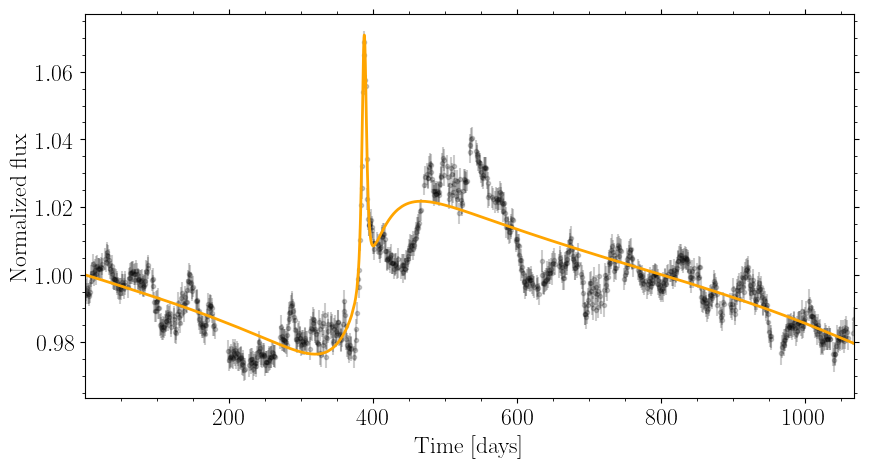

In [108]:
# Load Hu+2020 binned light curve of Spikey 
df = pd.read_csv(ddir / 'data_spikey_QDM_kepler_smith2016.csv')

# Generate relativistic Spikey model
params = smbhb.model_params()
params.sigma = 0
params.t0 = 1.0544
model = smbhb.model(params)
dm_kepler = model.light_curve(df.time.to_numpy(), df=True)

# Create a 1-d binned light curve and plot
df_kepler = ut.bin_lc(df, bin_size=1)
time_kepler = df.time.to_numpy()

# Plot light curve
fig, ax = pt.plot_lc(df_kepler, dm_kepler, cm=cm, alpha=0.2);

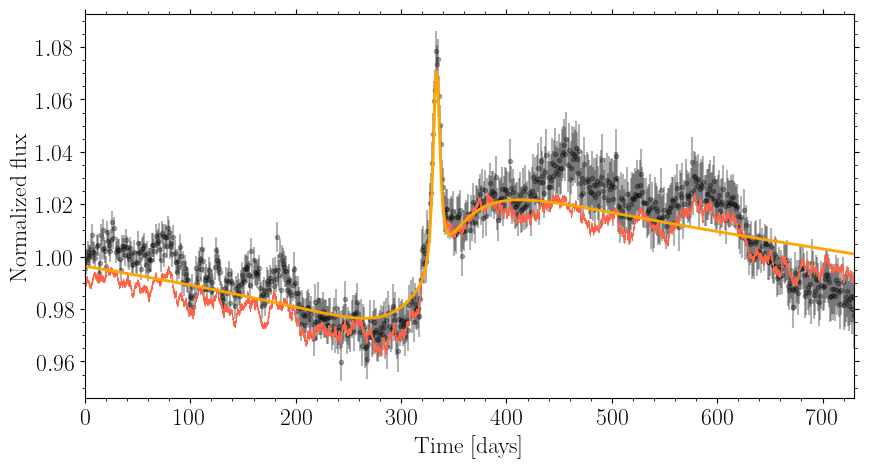

In [109]:
# Load Hu+2020 binned light curve of Spikey 
df = pd.read_feather(ddir / 'lc_spikey_fiducial_1h.ftr')

# Bin to 1-hour light curve 
df = ut.bin_lc(df, bin_size=1)
time = df.time.to_numpy()

# Generate relativistic Spikey model
params = smbhb.model_params()
params.t0    = 0.712
params.sigma = 0 
params.seed  = params.seed
model = smbhb.model(params)
dm_plato = model.light_curve(time, df=True)

# Load variable template
sdir = path / '../workdir/smbhb/simulations/lcs/'
dv_plato = pd.read_csv(sdir / 'varsource' / 'varsource_spikey_fiducial.txt', 
                 sep=' ', names=['time', 'dmag'])
dv_plato.time /= 86400
dv_plato['flux'] = ut.mag2flux(dv_plato.dmag)

# Cut light curve to 2-year duration
tdur = 2 * ut.year2day()
df_plato = df[df.time < 2*tdur]

# Set first exposure to zero
t0_offset = df_plato.time.iloc[0]
df_plato.time -= t0_offset
dv_plato.time -= t0_offset
dm_plato.time -= t0_offset
time_plato = df_plato.time.to_numpy()

# Plot light curve
fig, ax = pt.plot_lc(df_plato, dv_plato, cm=cv, lw=0.5, alpha=0.3)
ax.plot(dm_plato.time, dm_plato.flux, '-', c=cm, lw=2);

# Add offset to Plato light curve
t0_kepler = 1.05
t0_plato  = 1.195
df_plato.time += (t0_plato - t0_kepler) * ut.year2day()
df_plato.time += 8 * smbhb._period_observed(params.P, params.z) * ut.year2day()

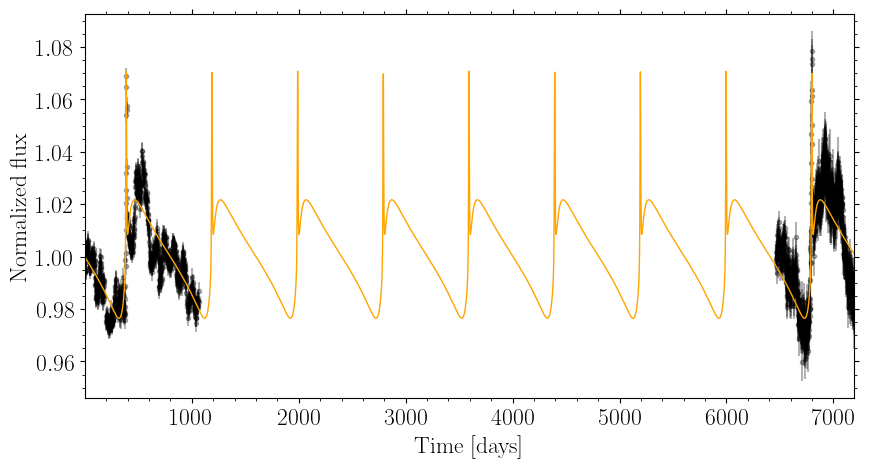

In [110]:
# Combine datasets
df = pd.concat((df_kepler, df_plato)) 
time = df.time.to_numpy()
flux = df.flux.to_numpy()

# Generate relativistic Spikey model
params = smbhb.model_params()
params.sigma = 0 
params.seed  = params.seed
model = smbhb.model(params)
tm = np.arange(df.time.iloc[0], df.time.iloc[-1], 1)
dm = model.light_curve(tm, df=True)

# Plot merged light curves
fig, ax = pt.plot_lc(df, dm, cm=cm, lw=1, alpha=0.3)
# ax.set_xlim(6750, 6850)
# ax.set_xlim(360, 420)
# fig.savefig(odir/'lc_combined.png', bbox_inches='tight', dpi=200)

---
### 1.1. Model Q
```
INFO:jaxns:Number of Markov-chains set to: 2000
Running over 6 devices.
--------
Termination Conditions:
Small remaining evidence
--------
likelihood evals: 8546440
samples: 33066
phantom samples: 0
likelihood evals / sample: 258.5
phantom fraction (%): 0.0%
--------
logZ=6460.382 +- 0.07
max(logL)=6468.61
H=-6.73
ESS=3212
--------
mean: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
mean: 0.9975 +- 0.0073 | 0.9888 / 0.9978 / 1.0063 | 0.998 | 0.998
--------
sigma: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
sigma: 0.0193 +- 0.0038 | 0.0154 / 0.0186 / 0.0242 | 0.017 | 0.017
--------
tau: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
tau: 158.0 +- 70.0 | 95.0 / 141.0 / 239.0 | 117.0 | 117.0
--------
CPU times: user 5h 8min 37s, sys: 5min 53s, total: 5h 14min 31s
Wall time: 1h 7min 35s
```

In [111]:
filename = rdir / 'spikey_combined_jaxns_24h2yr_Q.npy'
priors = {
    'tau'  : dist.LogNormal(jnp.log(100.0), 1.0),
    'sigma': dist.LogNormal(jnp.log(jnp.std(flux)), 0.5),
    'mean' : dist.Normal(jnp.mean(flux), 0.5),
}

In [39]:
# %%time
# result = bs.run_jaxns(
#     df, params, priors, 
#     build_mean=None, 
#     build_kernel=bs.drw_kernel, 
#     ofile=filename
# )

In [112]:
result = ut.load_result(filename)

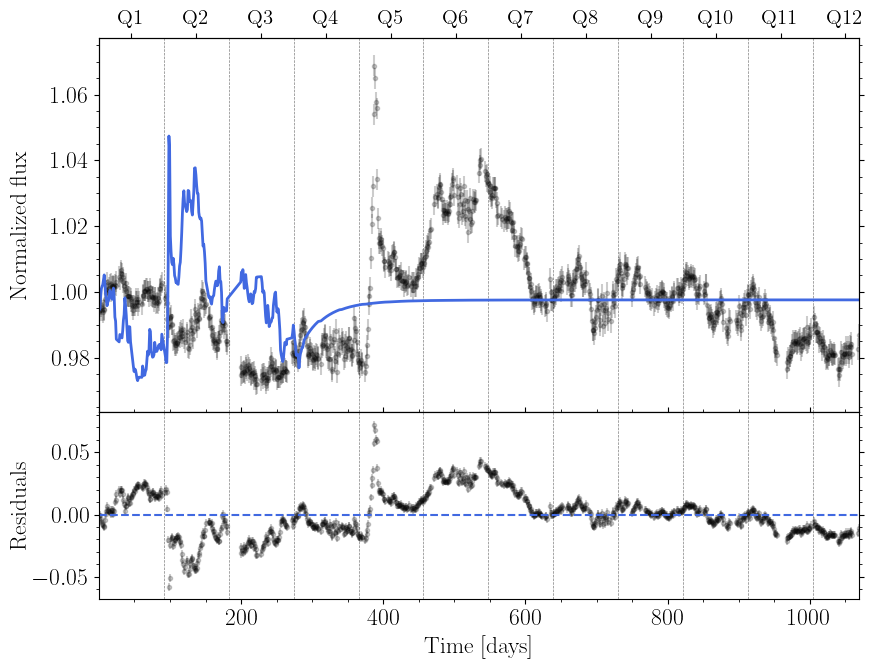

In [118]:
dm = bs.model_lightcurve_drw(time, result)
dm_kepler = dm.loc[:df_kepler.shape[0]-1]
# dm_plato  = dm[dm.time > 1500]
fig, ax = pt.plot_result(df_kepler, dm_kepler, Q0=1)
# fig = pt.plot_corner(result, best_params='mle', true_params=True);

# fig0, ax = pt.plot_result(df, dm, cm=c1, Q0=1, alpha=0.2)
# fig1 = pt.plot_corner(result, best_params='mle', true_params=True, color=c1);

# # Plot best-fit to Kepler light curve
# dm_kepler = bs.model_lightcurve_drw(df_kepler.time.to_numpy(), result)
# fig, ax = pt.plot_result(df_kepler, dm_kepler, Q0=1)
# # Plot best-fit to Plato light curve
# dm_plato = bs.model_lightcurve_drw(df_plato.time.to_numpy(), result)
# fig, ax = pt.plot_result(df_plato, dm_plato, Q0=1)

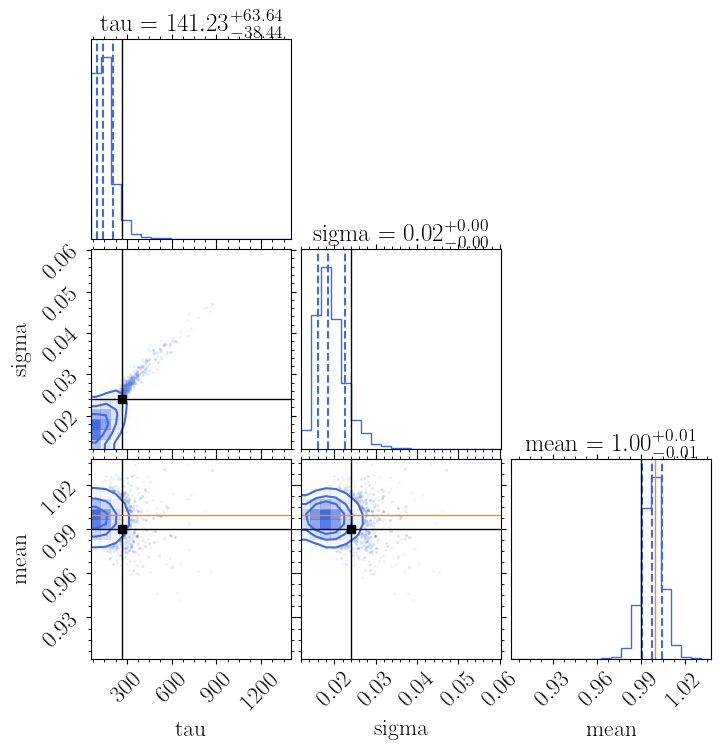

In [119]:
# Plot coner for combined model
fig = pt.plot_corner(result, best_params='mle', true_params=True);

In [120]:
# Print percentiles for latex
ut.get_percentiles(result, latex=True);

tau : pmx { 141.2346 }{ -38.4360 }{ 63.6390 }
sigma : pmx { 0.0186 }{ -0.0026 }{ 0.0039 }
mean : pmx { 0.9978 }{ -0.0070 }{ 0.0064 }


---
### 1.2. Model DM
```
INFO:jaxns:Number of Markov-chains set to: 2000
Running over 6 devices.
--------
Termination Conditions:
Reached max samples
--------
likelihood evals: 112646761
samples: 100200
phantom samples: 0
likelihood evals / sample: 1124.2
phantom fraction (%): 0.0%
--------
logZ=4427.75 +- 0.2
max(logL)=4491.27
H=-53.84
ESS=9224
--------
L: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
L: 0.712 +- 0.019 | 0.708 / 0.711 / 0.72 | 0.705 | 0.705
--------
P: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
P: 1.143687 +- 4.3e-05 | 1.143631 / 1.143687 / 1.143741 | 1.143679 | 1.143679
--------
alpha: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
alpha: -0.7 +- 0.1 | -0.74 / -0.7 / -0.62 | -0.68 | -0.68
--------
e: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
e: 0.4818 +- 0.0052 | 0.4763 / 0.4807 / 0.4884 | 0.4708 | 0.4708
--------
i: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
i: 83.75 +- 0.19 | 83.56 / 83.76 / 83.87 | 83.92 | 83.92
--------
logM1: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
logM1: 6.944 +- 0.043 | 6.923 / 6.941 / 6.975 | 6.92 | 6.92
--------
logM2: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
logM2: 7.703 +- 0.056 | 7.685 / 7.702 / 7.74 | 7.668 | 7.668
--------
t0: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
t0: 1.0451 +- 0.0011 | 1.0438 / 1.0451 / 1.0465 | 1.0447 | 1.0447
--------
w: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
w: 260.0 +- 5.9 | 259.6 / 260.2 / 260.9 | 260.3 | 260.3
--------
CPU times: user 1d 3h 14min 17s, sys: 10min 4s, total: 1d 3h 24min 22s
Wall time: 4h 31min 32s
```

In [121]:
filename = rdir / 'spikey_combined_jaxns_24h2yr_DM.npy'
priors = {
    'z'    : params.z,
    't0'   : dist.Uniform(0, 3),
    'P'    : dist.Uniform(0, 5),
    'i'    : dist.Uniform(0, 90),
    'e'    : dist.Uniform(0, 1),
    'w'    : dist.Uniform(0, 360),
    'logM1': dist.Uniform(5, 11),
    'logM2': dist.Uniform(5, 11),
    'alpha': dist.Uniform(-4, 4),
    'L'    : dist.Uniform(0, 1),
    'vz'   : params.vz,
}

In [50]:
# %%time
# result = bs.run_jaxns(
#     df, params, priors, 
#     build_mean=bs.smbhb_mean_builder,
#     build_kernel=None, 
#     ofile=filename
# )

In [122]:
result = ut.load_result(filename)

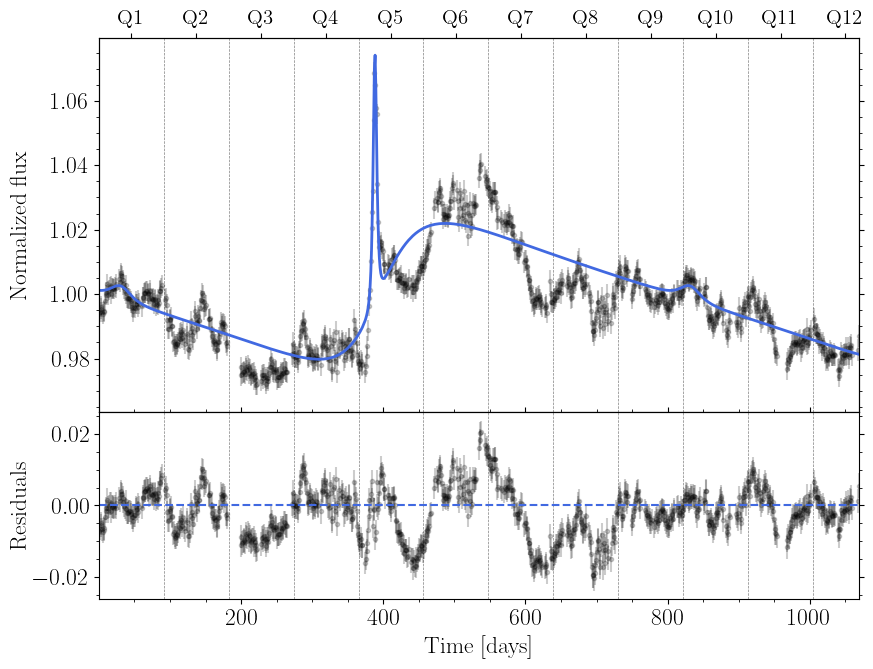

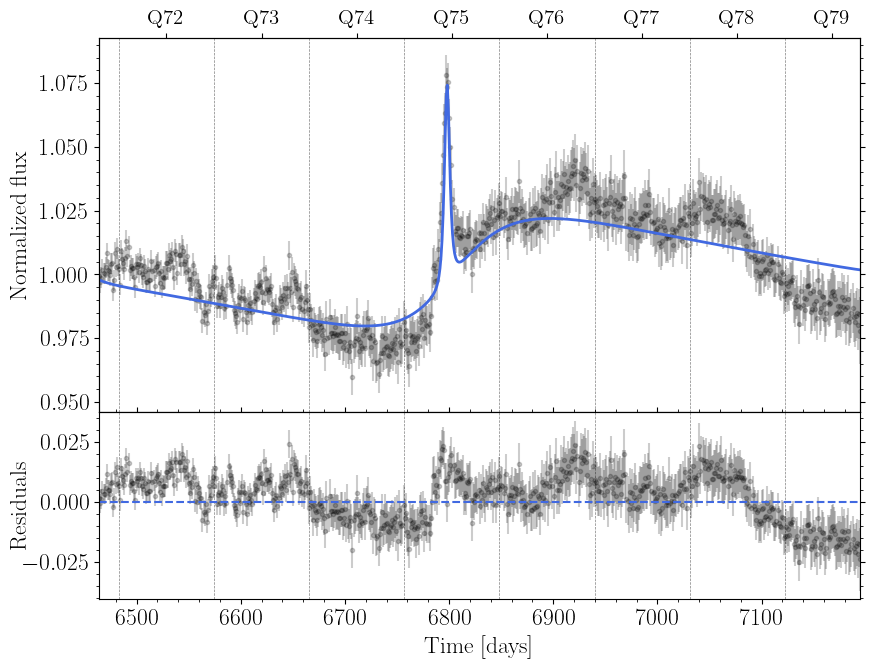

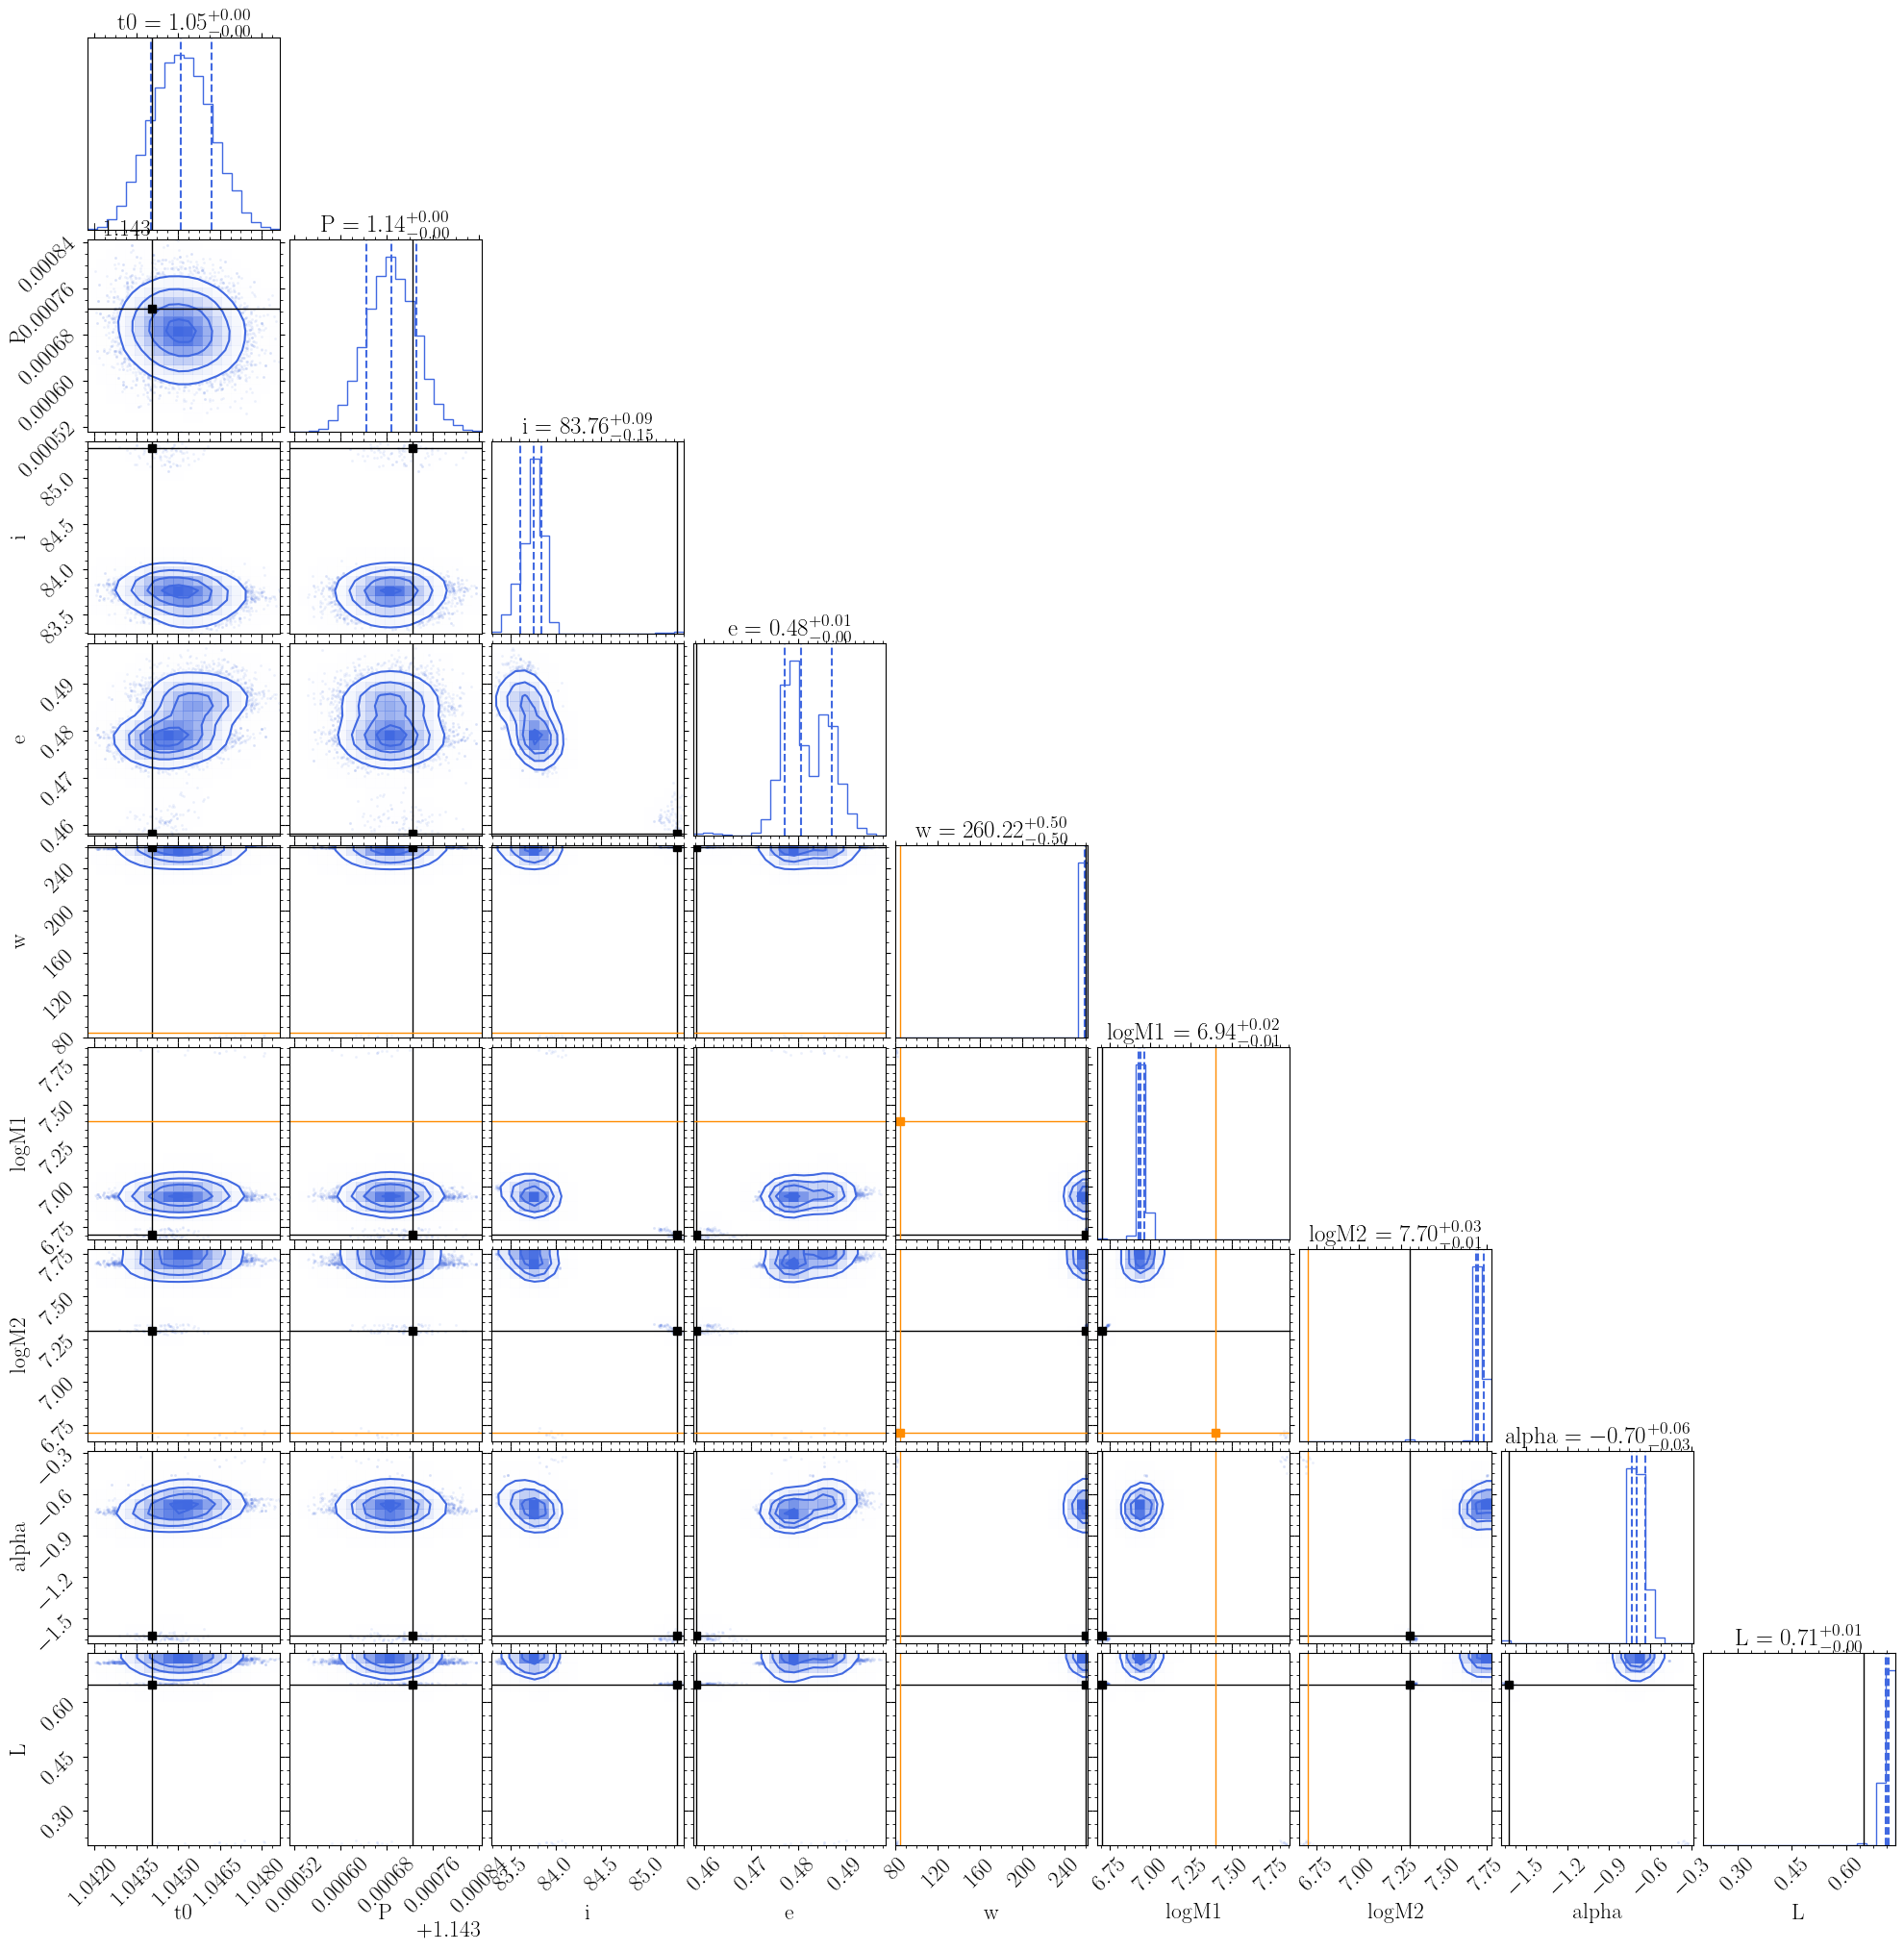

In [123]:
# Plot best-fit to Kepler light curve
dm_kepler = smbhb.model_lightcurve(df_kepler.time.to_numpy(), result['likelihood']['mle'])
fig, ax = pt.plot_result(df_kepler, dm_kepler, Q0=1)
# Plot best-fit to Plato light curve
dm_plato = smbhb.model_lightcurve(df_plato.time.to_numpy(), result['likelihood']['mle'])
fig, ax = pt.plot_result(df_plato, dm_plato, Q0=1)
# Plot coner for combined model
fig = pt.plot_corner(result, best_params='mle', true_params=True);

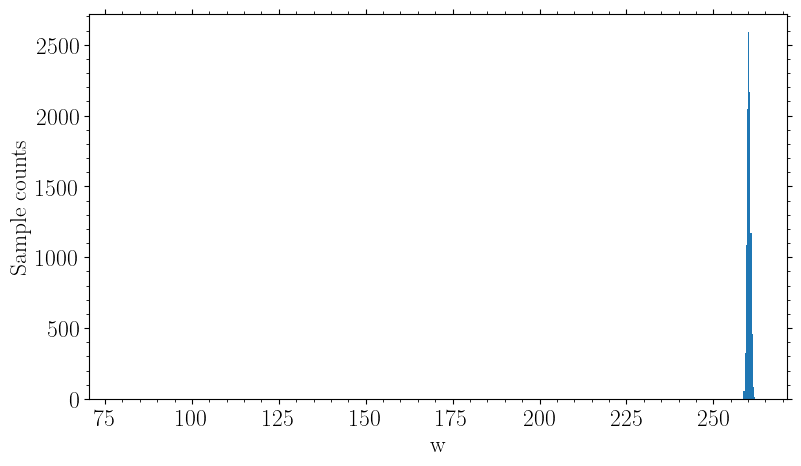

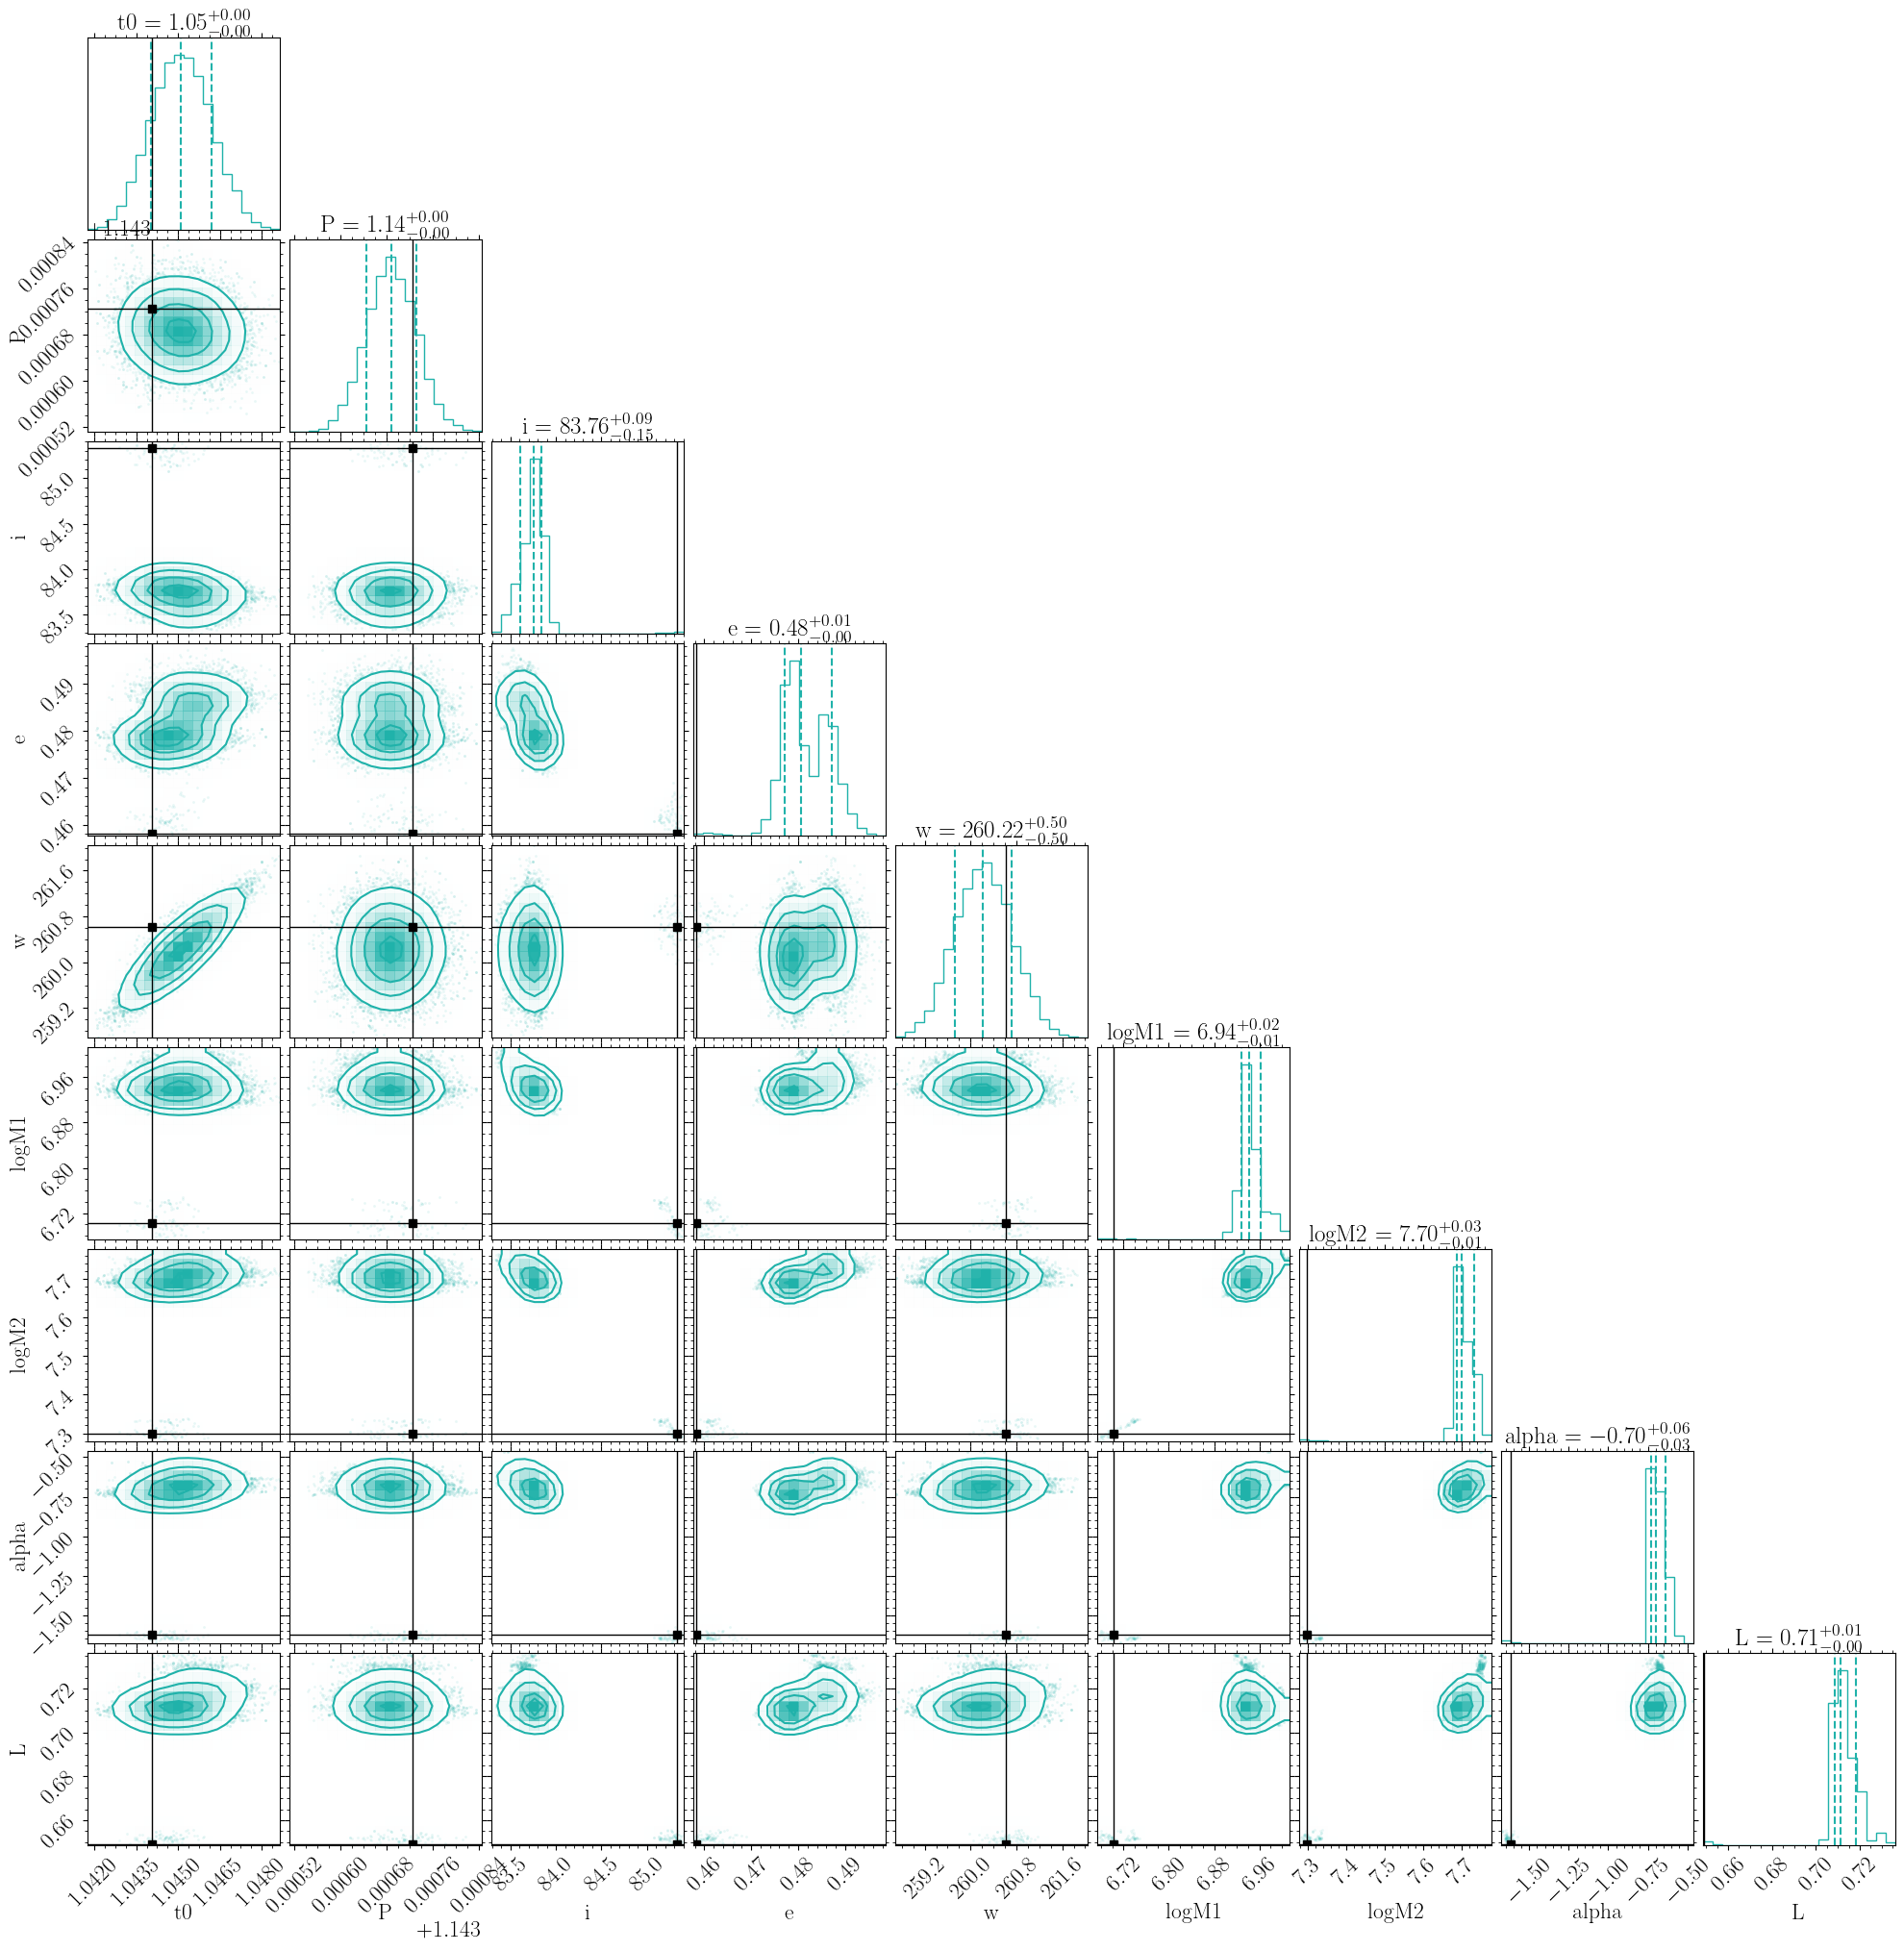

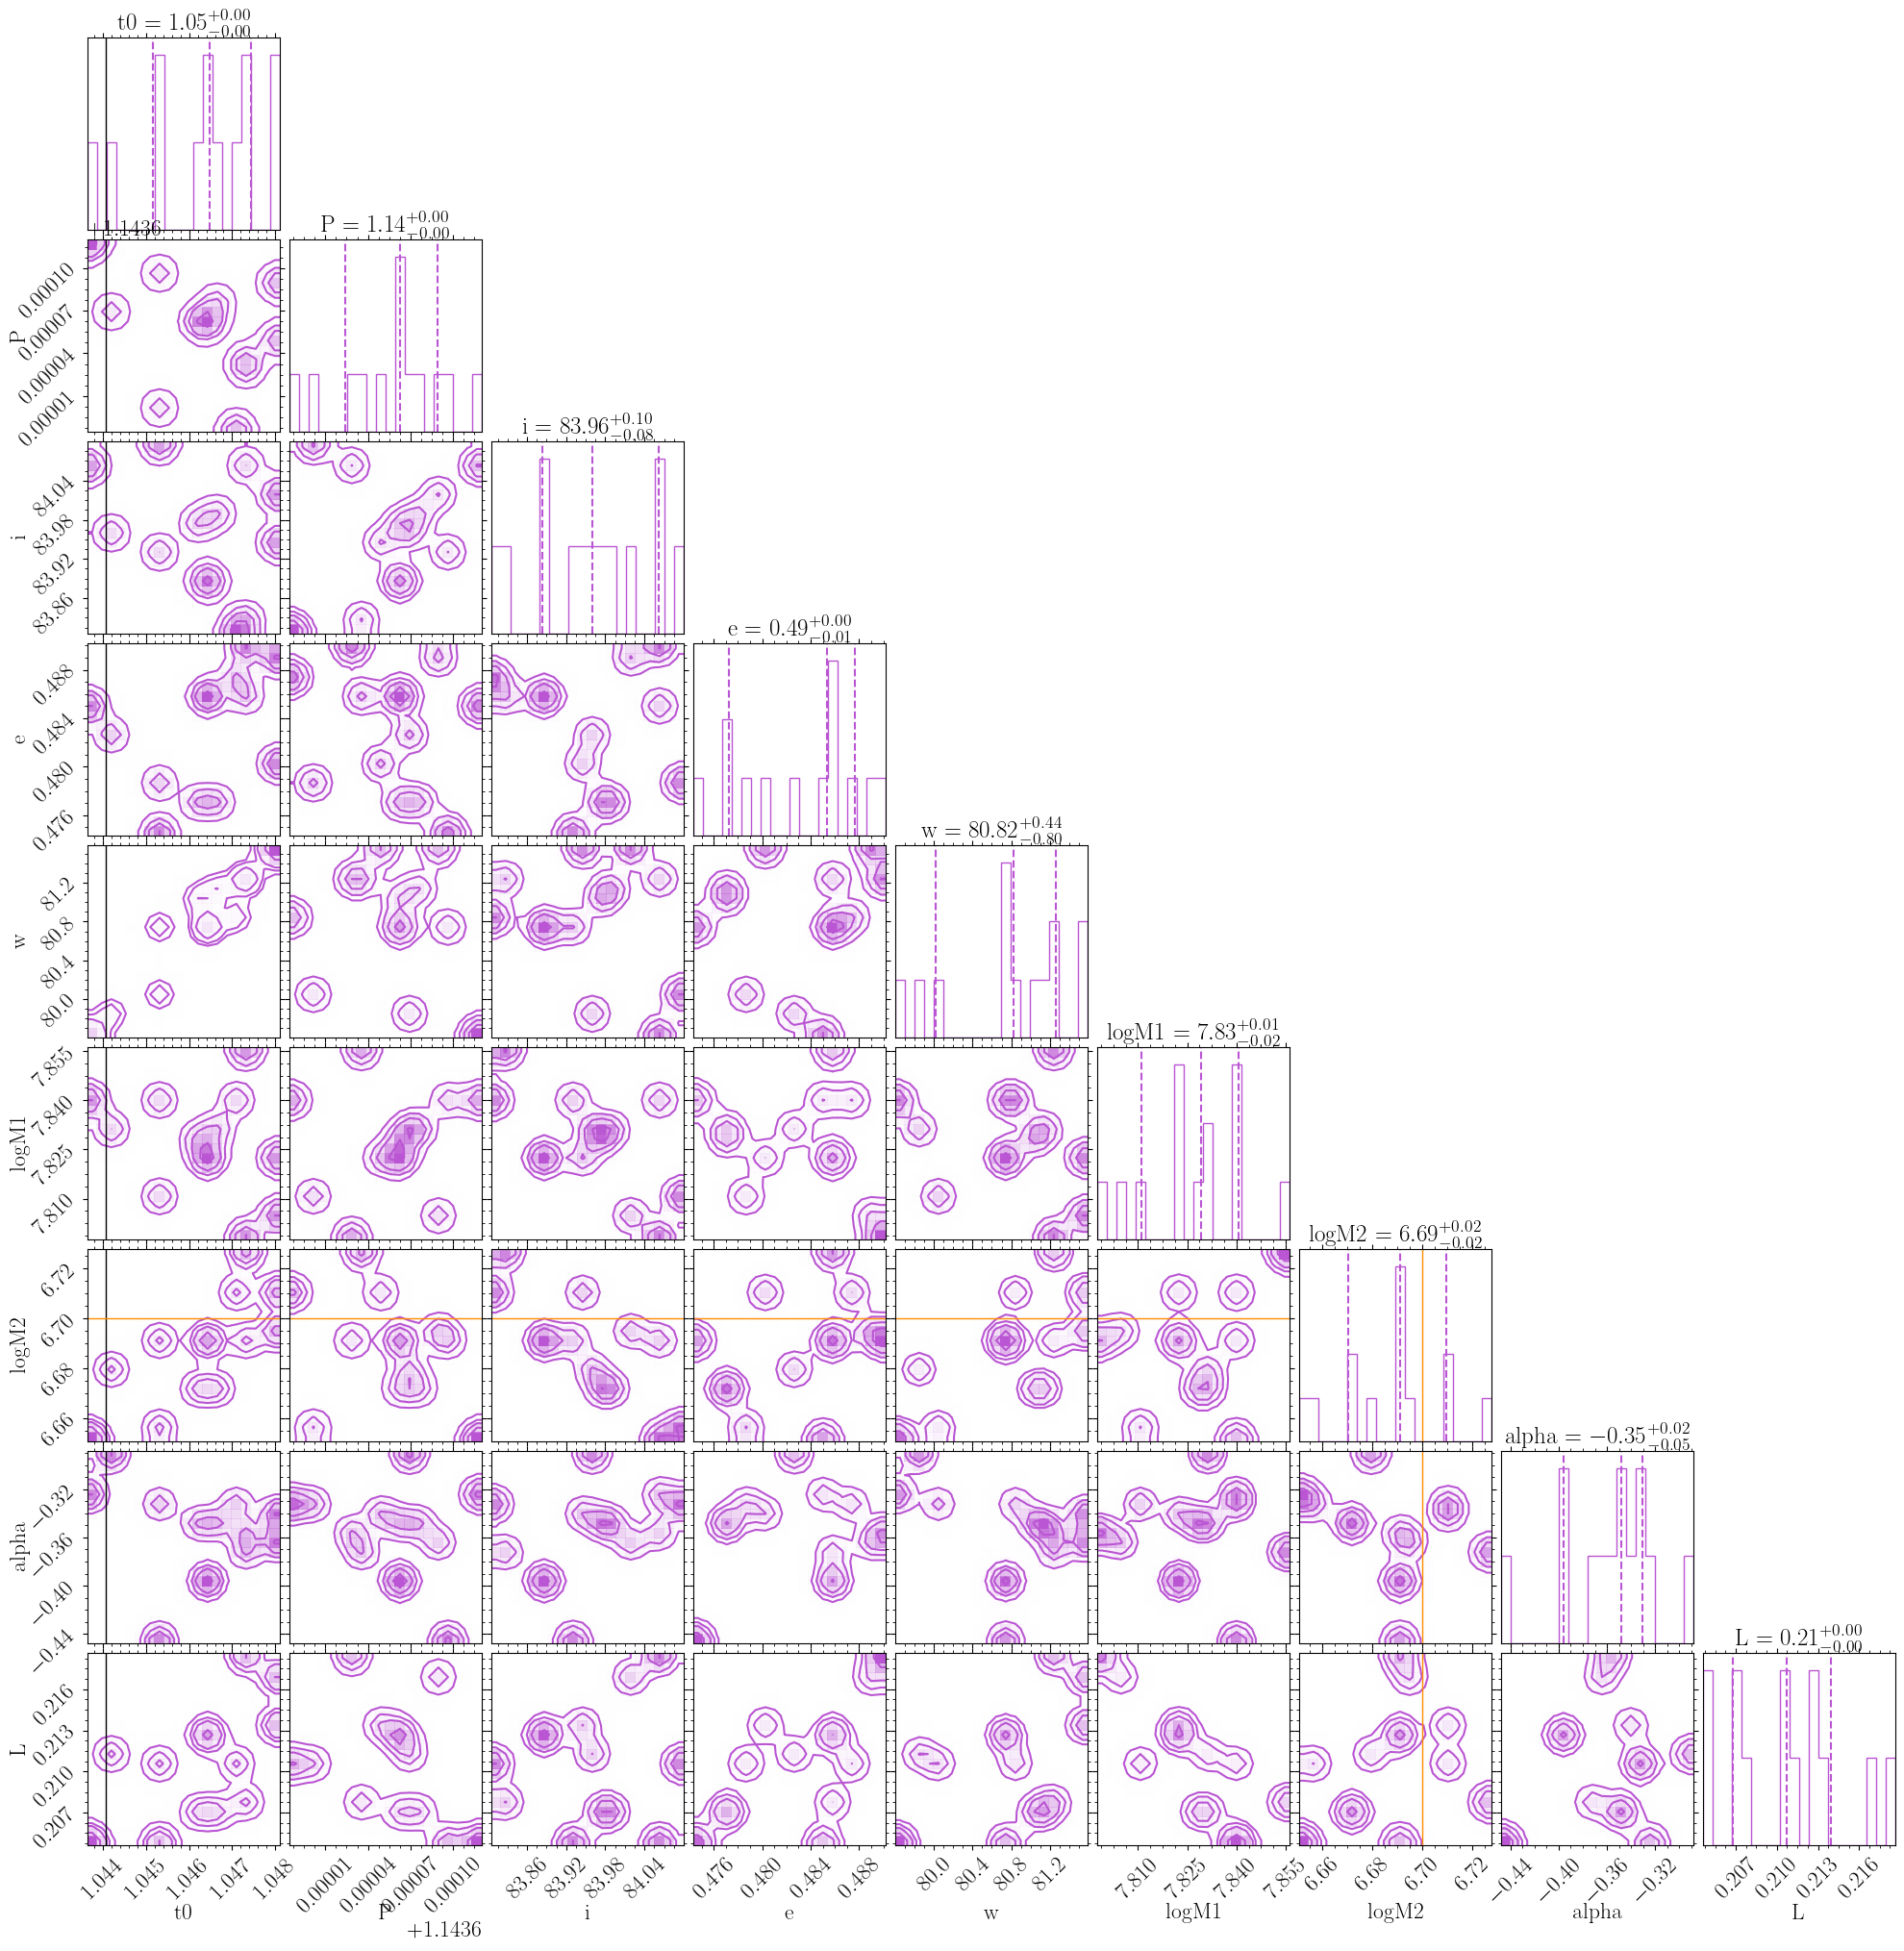

In [124]:
# Resolve bimodality in w
clusters_w = bs.get_posterior_clusters(df, result, param_cluster='w', n_components=2)
result_w0 = clusters_w[0]
result_w1 = clusters_w[1]
fig = pt.plot_corner(result_w0, best_params='mle', true_params=True, color=c0)
fig = pt.plot_corner(result_w1, best_params='mle', true_params=True, color=c1)

In [125]:
# Print percentiles for latex
ut.get_percentiles(result_w0, latex=True);

t0 : pmx { 1.04510 }{ -0.00106 }{ 0.00109 }
P : pmx { 1.14369 }{ -0.00004 }{ 0.00004 }
i : pmx { 83.75793 }{ -0.14824 }{ 0.08815 }
e : pmx { 0.48061 }{ -0.00347 }{ 0.00665 }
w : pmx { 260.22188 }{ -0.49917 }{ 0.50372 }
logM1 : pmx { 6.94139 }{ -0.01292 }{ 0.02125 }
logM2 : pmx { 7.70128 }{ -0.01350 }{ 0.03157 }
alpha : pmx { -0.69829 }{ -0.03168 }{ 0.05978 }
L : pmx { 0.71134 }{ -0.00272 }{ 0.00712 }


---
### 1.3. Model QDM

In [126]:
filename = rdir / 'spikey_combined_jaxns_24h2yr_QDM.npy'
priors = {
    'z'    : params.z,
    'vz'   : params.vz,
    't0'   : dist.Uniform(0, 3),
    'P'    : dist.Uniform(0, 5),
    'i'    : dist.Uniform(0, 90),
    'e'    : dist.Uniform(0, 1),
    'w'    : dist.Uniform(0, 360),
    'logM1': dist.Uniform(5, 11),
    'logM2': dist.Uniform(5, 11),
    'alpha': dist.Uniform(-4, 4),
    'L'    : dist.Uniform(0, 1),
    'tau'  : dist.LogNormal(jnp.log(100.0), 1.0),
    'sigma': dist.LogNormal(jnp.log(jnp.std(flux)), 0.5),
}

In [ ]:
%%time 
result = bs.run_jaxns(
    df, params, priors, 
    build_mean=bs.smbhb_mean_builder, 
    build_kernel=bs.drw_kernel, 
    ofile=filename
)

INFO:jaxns:Number of Markov-chains set to: 2000


Running over 6 devices.


In [ ]:
result = ut.load_result(filename)

In [ ]:
# Show results of QDM and DM model
dm_QDM = bs.model_lightcurve_drw(time, result)
dm_DM = smbhb.model_lightcurve(time, result['likelihood']['mle'])
fig, ax = pt.plot_result(df, dm_QDM, Q0=Q0)
ax[0].plot(dm_DM.time, dm_DM.flux, c=c0, lw=2)
fig = pt.plot_corner(result, best_params='mle', true_params=True);

In [ ]:
# Resolve bimodality in w
clusters_w = bs.get_posterior_clusters(df, result_t0, param_cluster='w', n_components=2)
result_w0 = clusters_w[0]
result_w1 = clusters_w[1]
fig = pt.plot_corner(result_w0, best_params='mle', true_params=True, color=c0);
fig = pt.plot_corner(result_w1, best_params='mle', true_params=True, color=c1);

In [ ]:
# Print percentiles for latex
ut.get_percentiles(result, latex=True);

---
## 2. *Kepler* + *Plato* 4-yr light curve
---